# Foreground Maps Visualization

Generate and visualize key astrophysical foregrounds at 21cm frequencies: synchrotron emission, free-free emission, and point sources. These represent the dominant contamination sources that must be cleaned to detect dark photon signals.

## Setup

In [ ]:
import sys
import matplotlib_inline
sys.path.append("../")

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

# PySM3 for foreground modeling
import pysm3
import pysm3.units as u
import healpy as hp

import numpy as np
import pymaster as nmt  # For angular power spectrum analysis

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Load custom plotting parameters
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Generate Foreground Maps

Create maps of the three dominant foreground components at 410 MHz using PySM3 models.

In [ ]:
nside = 2048  # HEALPix resolution
nu = 1430. * u.MHz  # Frequency corresponding to 21cm at z~4.3

# Free-free emission (thermal bremsstrahlung from ionized gas)
freefreesky = pysm3.Sky(nside=nside, preset_strings=["f1"])
freefree_map = freefreesky.get_emission(nu)
freefree_map = freefree_map.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))

# Synchrotron emission (relativistic electrons in magnetic fields)
syncsky = pysm3.Sky(nside=nside, preset_strings=["s1"])
sync_map = syncsky.get_emission(nu)
sync_map = sync_map.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))

amesky = pysm3.Sky(nside=nside, preset_strings=["a1"])
ame_maps = amesky.get_emission(nu)
ame_maps = ame_maps.to(u.mK_CMB, equivalencies=u.cmb_equivalencies(nu))

# Point sources (radio galaxies, quasars, etc.)
pt_srcs = 1000 * np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/Tb_nu_map2048.npy")[...,0]

## Foreground Visualizations

Create Mollweide projections of each foreground component.

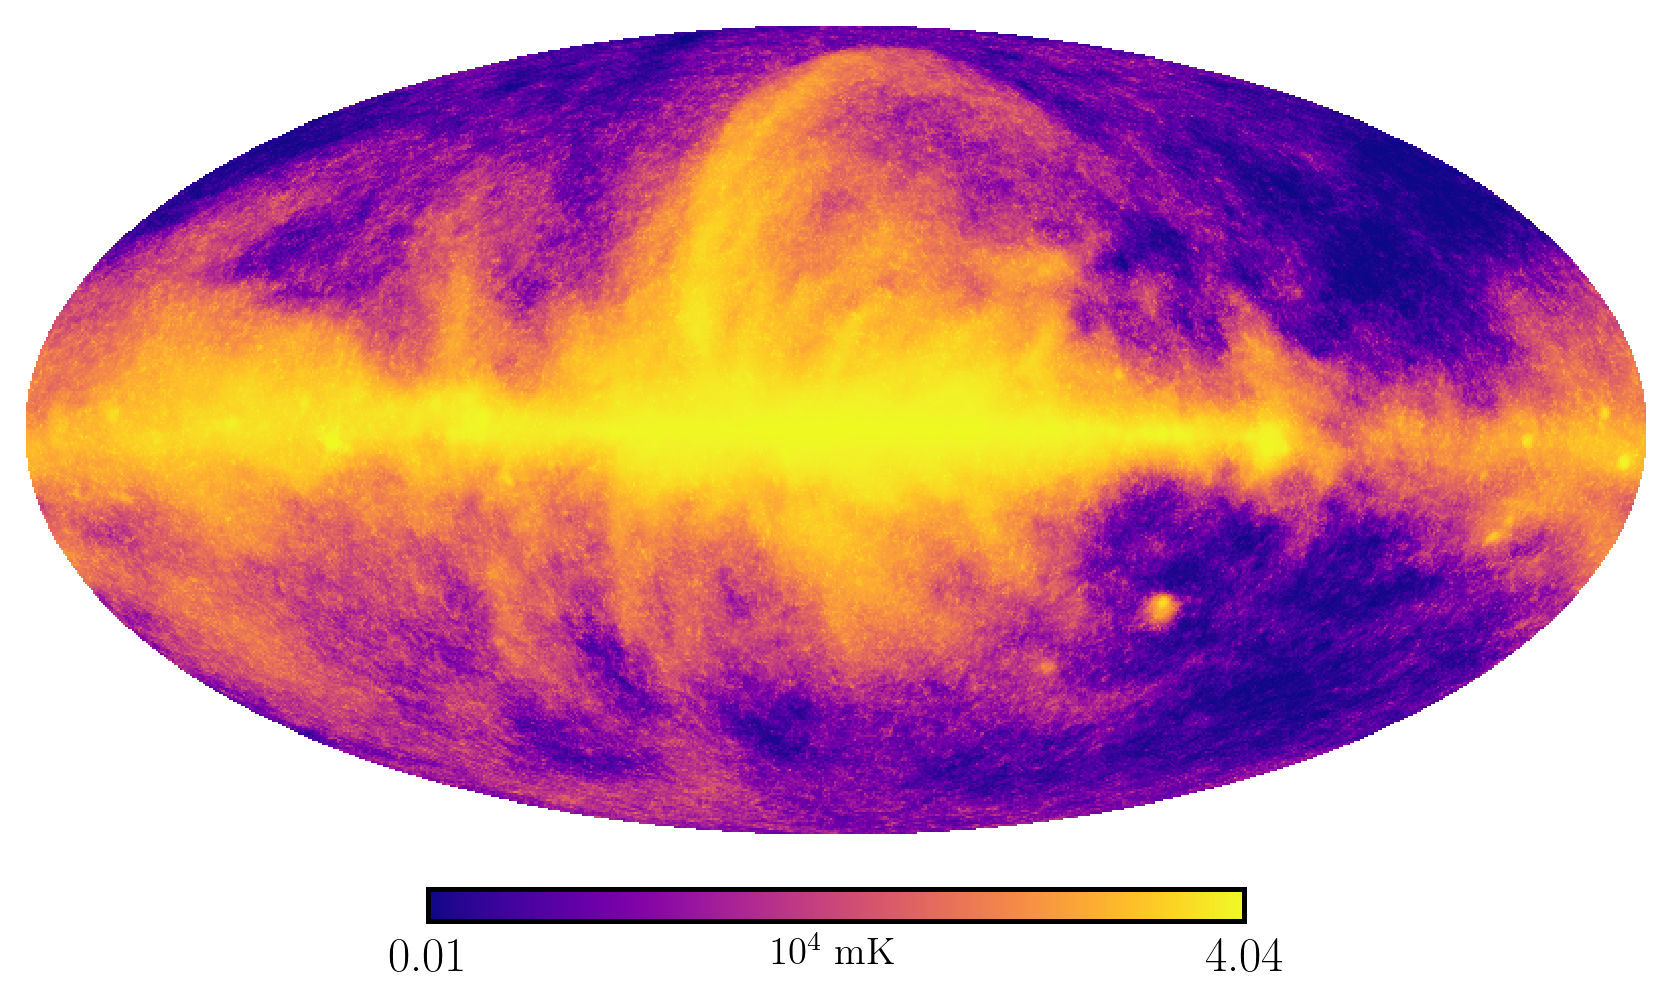

In [3]:
# Synchrotron emission map (dominant foreground at low frequencies)
hp.mollview(sync_map[0]/1e4, cmap="plasma", norm="hist", unit=r"$10^4$ mK", format="%.2f", title=None)
plt.savefig("plots/sync.pdf", bbox_inches="tight")
plt.savefig("plots/sync.png", dpi=500, bbox_inches="tight")

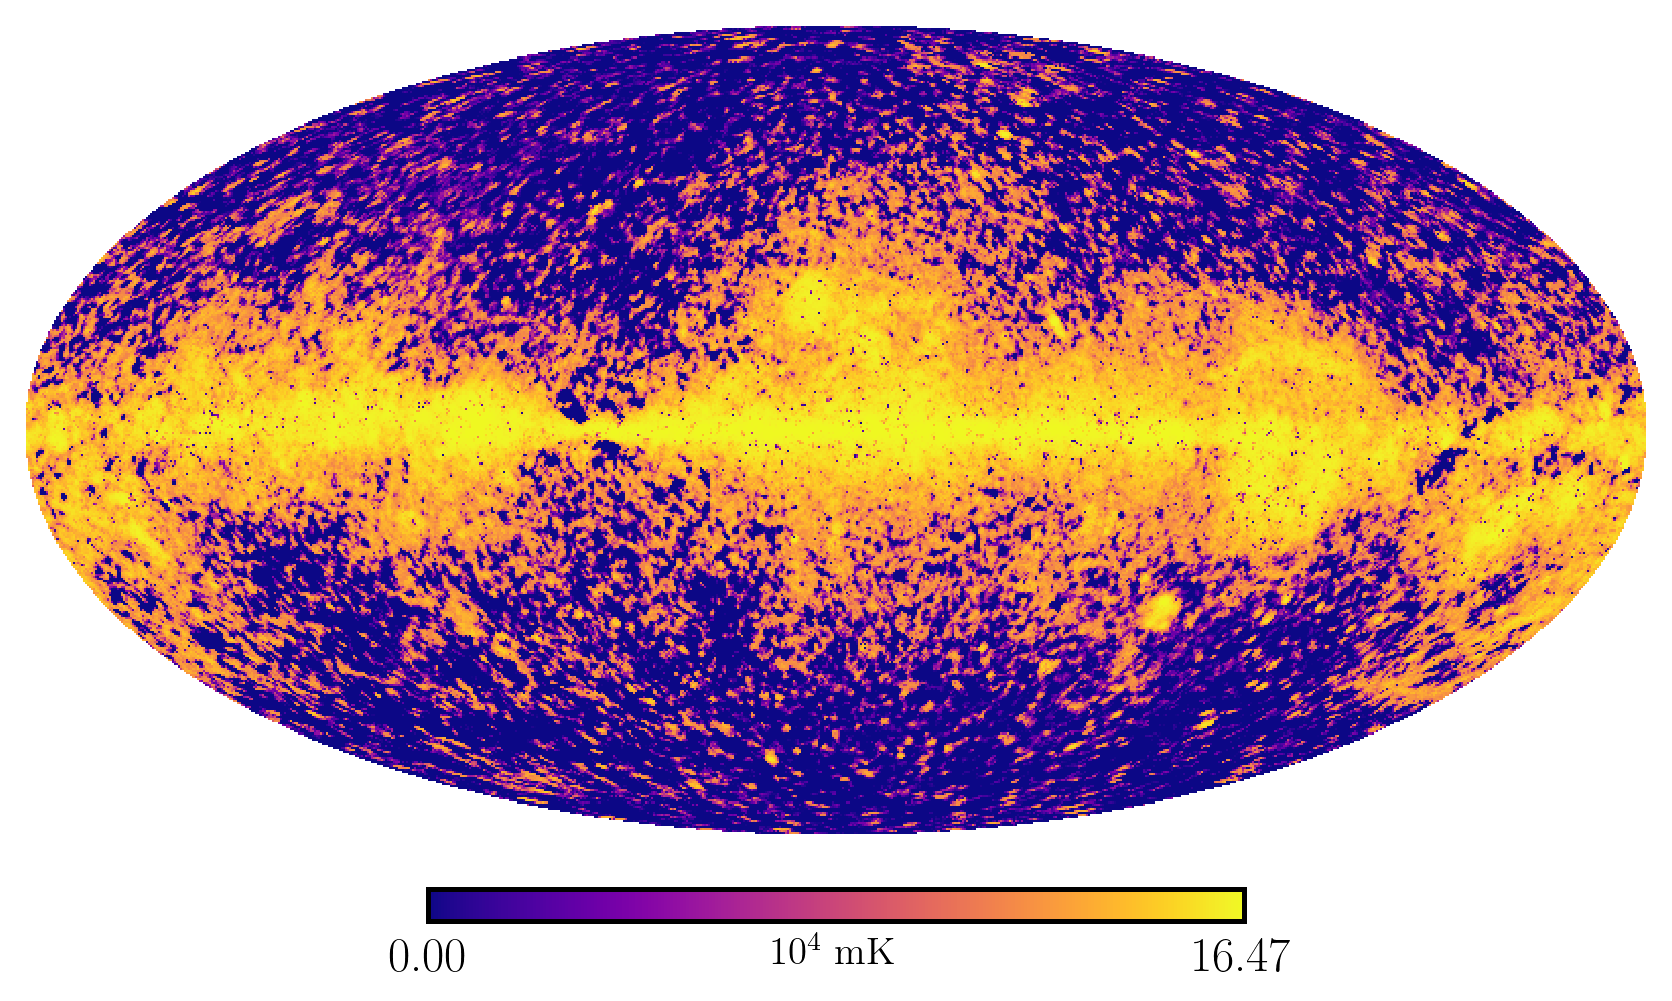

In [4]:
# Free-free emission map (thermal emission from ionized gas)
hp.mollview(freefree_map[0]/1e4, cmap="plasma", norm="hist", unit=r"$10^4$ mK", format="%.2f", title=None)
plt.savefig("plots/free_free.pdf", bbox_inches="tight")
plt.savefig("plots/free_free.png", dpi=500, bbox_inches="tight")

In [5]:
np.min(freefree_map[0]), np.max(freefree_map[0])

(<Quantity 0.00011298 mK_CMB>, <Quantity 164696.55250389 mK_CMB>)

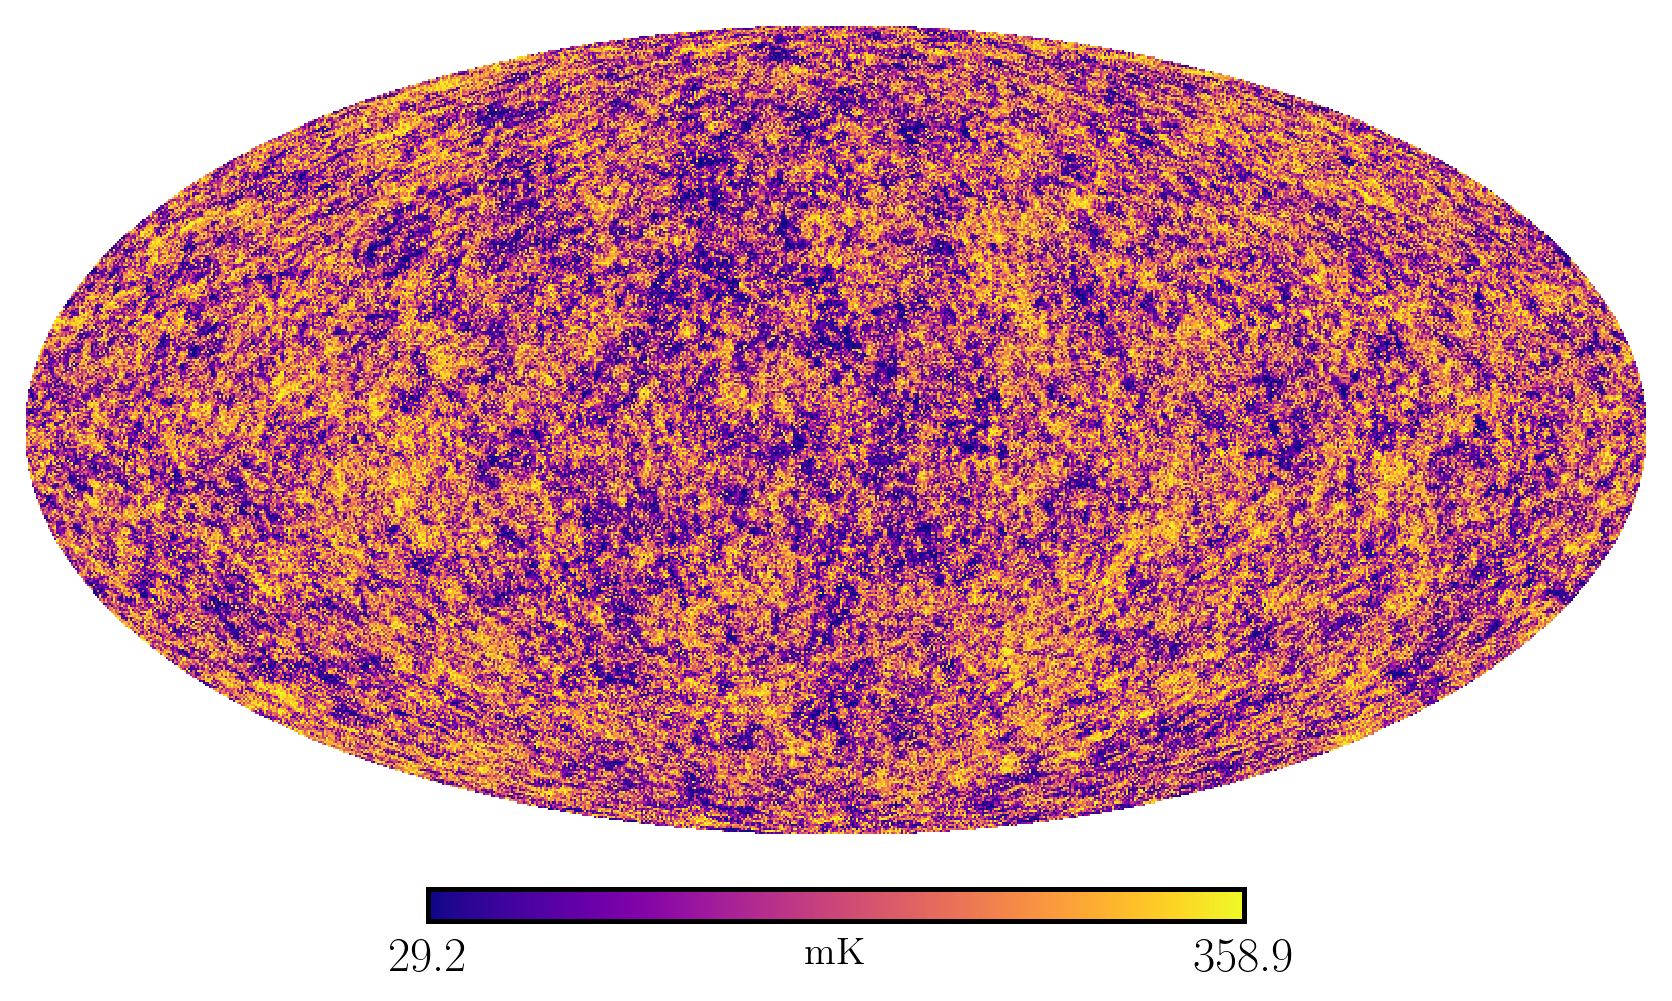

In [6]:
# Point source map (discrete radio sources)
hp.mollview(pt_srcs, cmap="plasma", norm="hist", unit=r"mK", format="%.1f", title=None)
plt.savefig("plots/pt_srcs.pdf", bbox_inches="tight")
plt.savefig("plots/pt_srcs.png", dpi=500, bbox_inches="tight")

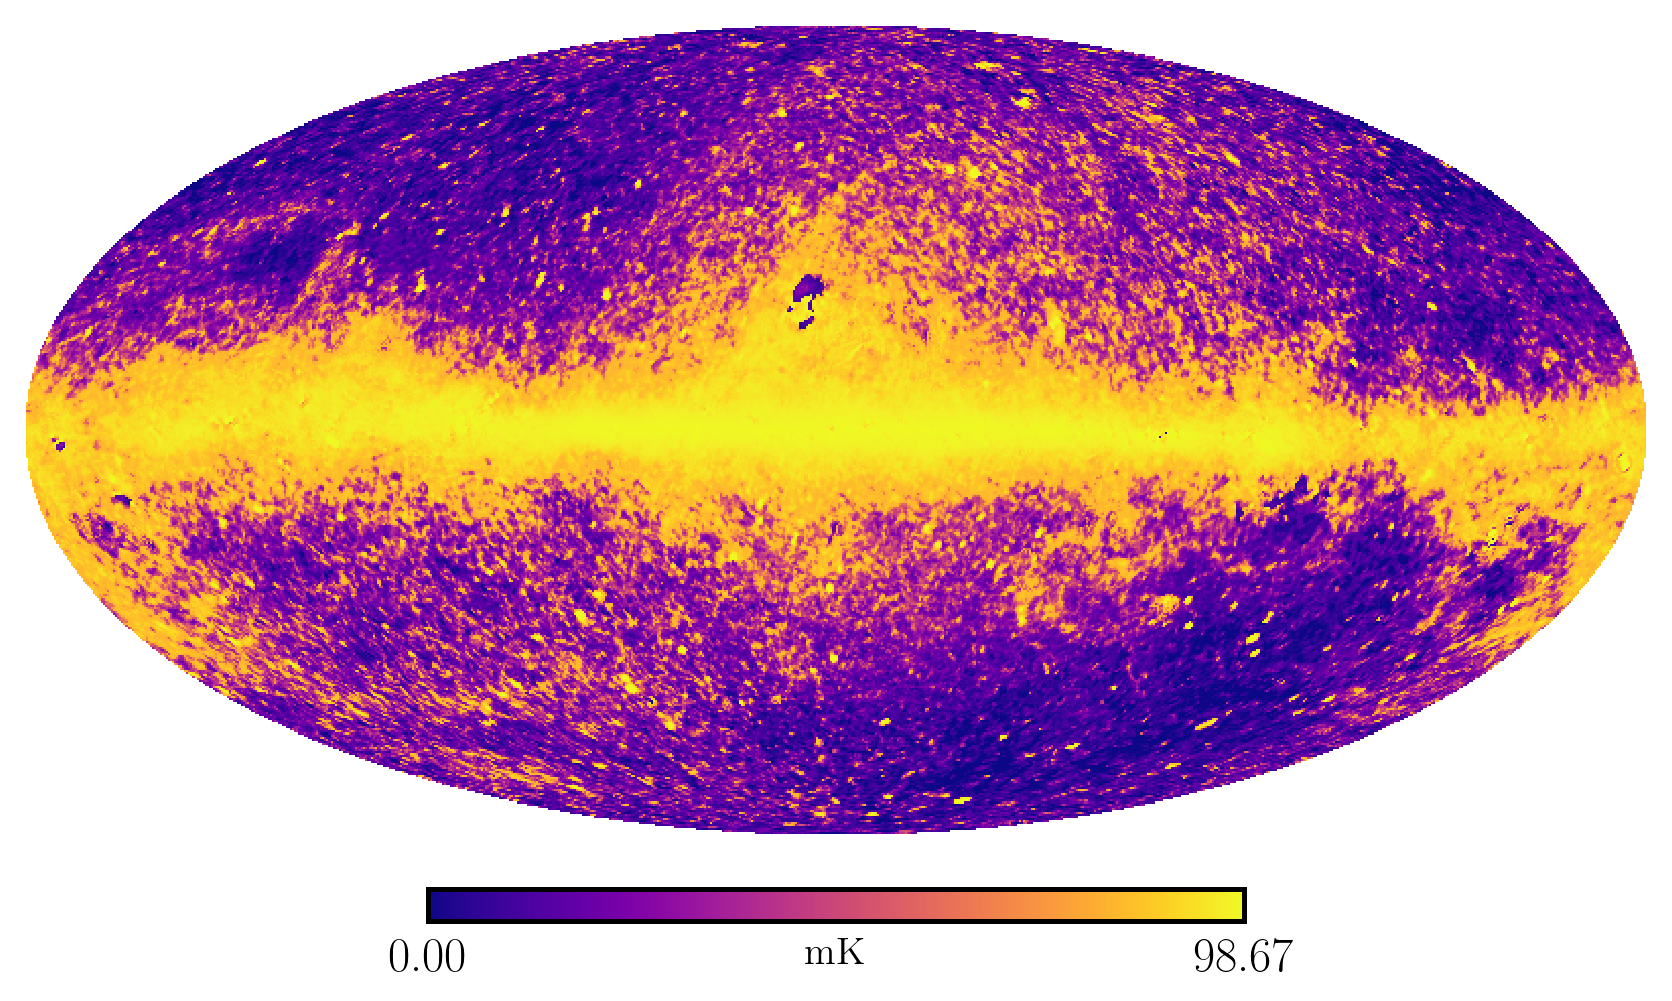

In [7]:
# AME emission map (dominant foreground at low frequencies)
hp.mollview(ame_maps[0], cmap="plasma", norm="hist", unit=r"mK", format="%.2f", title=None)
plt.savefig("plots/ame.pdf", bbox_inches="tight")
plt.savefig("plots/ame.png", dpi=500, bbox_inches="tight")